In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn import metrics

df = pd.read_csv('../../../data/komdigi_hoaks.csv')

df['teks'] = df['title'].fillna('') + ' ' + df['excerpt'].fillna('')
df = df[df['teks'].str.strip() != ''].reset_index(drop=True)

print("Total data hoaks:", len(df))
df[['title', 'teks']].head()


Total data hoaks: 4176


,title,teks
0,[HOAKS] Tautan Pencairan BSU September 2026 Se...,[HOAKS] Tautan Pencairan BSU September 2026 Se...
1,[HOAKS] Panas El Nino Berkaitan dengan Gelomba...,[HOAKS] Panas El Nino Berkaitan dengan Gelomba...
2,[HOAKS] Susu Bebelac Berbahaya karena Mengandu...,[HOAKS] Susu Bebelac Berbahaya karena Mengandu...
3,[HOAKS] Purbaya Informasikan Raffi Ahmad Beli ...,[HOAKS] Purbaya Informasikan Raffi Ahmad Beli ...
4,[HOAKS] Tautan Bantuan Laptop dan Ponsel untuk...,[HOAKS] Tautan Bantuan Laptop dan Ponsel untuk...


In [112]:
# ==========================================
# TF-IDF
# ==========================================

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['teks'])

print("Ukuran matriks TF-IDF:", X.shape)

Ukuran matriks TF-IDF: (4176, 8206)


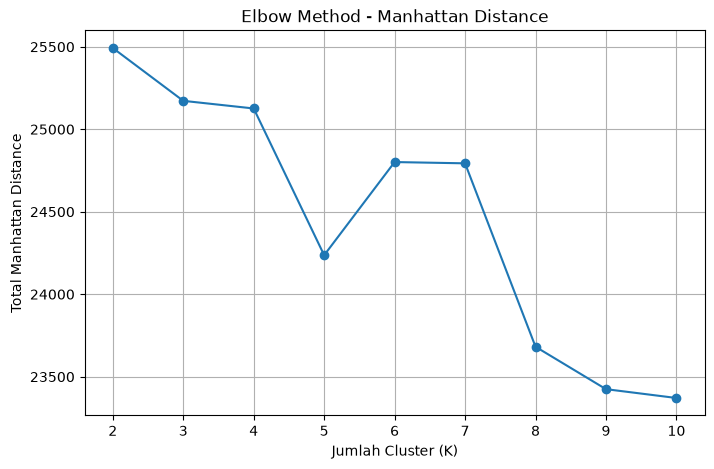

In [113]:
# ==========================================
# ELBOW METHOD - MANHATTAN
# ==========================================

K_range = range(2, 11)
manhattan_inertia = []
CHUNK_SIZE = 250

for k in K_range:

    # K-Means untuk mendapatkan centroid
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    ).fit(X)

    centroids = kmeans.cluster_centers_.astype(np.float32)
    total_distance = 0

    # Hitung Manhattan Distance per chunk
    for start in range(0, X.shape[0], CHUNK_SIZE):

        X_chunk = X[start:start + CHUNK_SIZE].toarray().astype(np.float32)

        distances = np.sum(
            np.abs(
                X_chunk[:, None, :] - centroids[None, :, :]
            ),
            axis=2
        )

        total_distance += np.min(distances, axis=1).sum()

    manhattan_inertia.append(total_distance)

# # ==========================================
# # HASIL
# # ==========================================

# for k, nilai in zip(K_range, manhattan_inertia):
#     print(f"K = {k} → Manhattan Distance = {nilai:.4f}")

# ==========================================
# VISUALISASI
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(K_range, manhattan_inertia, marker='o')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Total Manhattan Distance')
plt.title('Elbow Method - Manhattan Distance')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [114]:
# ==========================================
# K-MEANS
# ==========================================

n_clusters = 3

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

kmeans.fit(X)

print("Jumlah cluster:", n_clusters)
print("Bentuk centroid:", kmeans.cluster_centers_.shape)

Jumlah cluster: 3
Bentuk centroid: (3, 8206)


In [115]:
# ==========================================
# K-MEANS K = 3
# ==========================================

n_clusters = 3

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

kmeans.fit(X)

print("Jumlah cluster:", n_clusters)
print("Bentuk centroid:", kmeans.cluster_centers_.shape)

Jumlah cluster: 3
Bentuk centroid: (3, 8206)


In [116]:
hasil_jarak = pd.DataFrame(
    manhattan_dist,
    columns=[
        f'Distance_Cluster_{i}'
        for i in range(manhattan_dist.shape[1])
    ]
)

hasil_jarak['Cluster_Terpilih'] = manhattan_labels

print(hasil_jarak.head(10))

   Distance_Cluster_0  Distance_Cluster_1  Distance_Cluster_2  \
0            7.609293            7.896864            7.646981   
1            8.331266            8.441816            8.131003   
2            6.979902            7.034955            6.801591   
3            6.203689            6.422323            6.103288   
4            4.869886            5.610471            5.291760   
5            5.155031            5.402597            5.035845   
6            6.579943            6.673085            6.392666   
7            7.945466            8.024945            7.850957   
8            7.296644            7.483303            7.293542   
9            5.739791            6.596691            6.274750   

   Distance_Cluster_3  Distance_Cluster_4  Distance_Cluster_5  \
0            8.081726            7.918305            8.036265   
1            8.496395            8.713473            8.580121   
2            7.304931            7.311811            7.173130   
3            6.682862   

In [117]:
# ==========================================
# PENENTUAN CLUSTER
# ==========================================

labels_manhattan = np.argmin(
    manhattan_distance,
    axis=1
)

print("Bentuk label:", labels_manhattan.shape)
print("5 label pertama:", labels_manhattan[:5])

Bentuk label: (4176,)
5 label pertama: [0 2 2 2 0]


In [118]:
# ==========================================
# HASIL CLUSTER
# ==========================================

df['cluster'] = labels_manhattan

print(df[['title', 'cluster']].head(10))

                                               title  cluster
0  [HOAKS] Tautan Pencairan BSU September 2026 Se...        0
1  [HOAKS] Panas El Nino Berkaitan dengan Gelomba...        2
2  [HOAKS] Susu Bebelac Berbahaya karena Mengandu...        2
3  [HOAKS] Purbaya Informasikan Raffi Ahmad Beli ...        2
4  [HOAKS] Tautan Bantuan Laptop dan Ponsel untuk...        0
5          [HOAKS] Tautan Aktivasi Kartu ATM SeaBank        0
6  [HOAKS] Kemendikbud Bakal Melarang Guru Punya ...        2
7  [HOAKS] Menteri ESDM Bahlil Lahadalia akan Nai...        2
8  [HOAKS] Purbaya Jadi Ketua KPK Usai Dicopot da...        2
9  [HOAKS] Pendaftaran Dana Bantuan dari Tom Lembong        0


In [119]:
# ==========================================
# JUMLAH DATA SETIAP CLUSTER
# ==========================================

jumlah_cluster = df['cluster'].value_counts().sort_index()

print(jumlah_cluster)

cluster
0     716
2    3460
Name: count, dtype: int64


In [120]:
# ==========================================
# PCA
# ==========================================

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_dense)

print("Bentuk data setelah PCA:", X_pca.shape)

Bentuk data setelah PCA: (4176, 2)


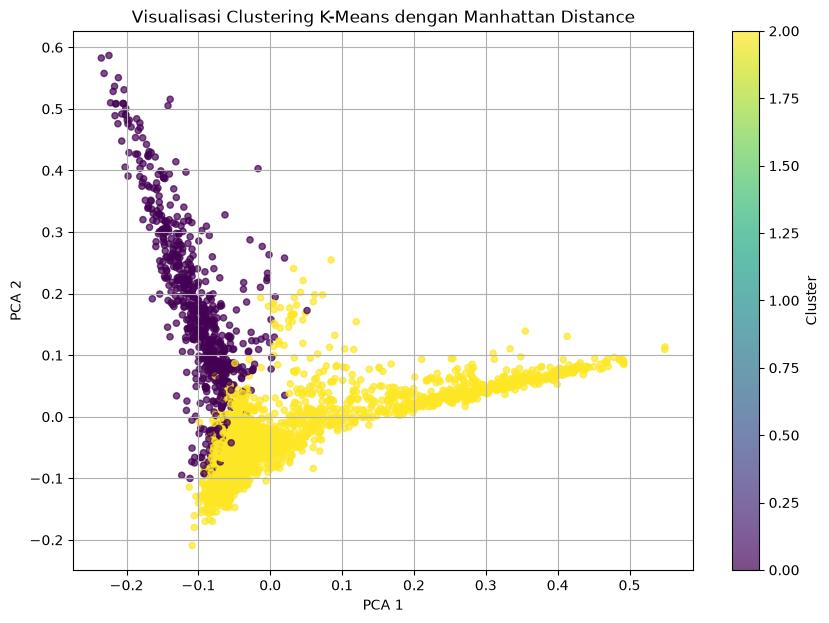

In [121]:
# ==========================================
# VISUALISASI CLUSTER
# ==========================================

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_manhattan,
    cmap='viridis',
    s=20,
    alpha=0.7
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Visualisasi Clustering K-Means dengan Manhattan Distance')

plt.colorbar(
    scatter,
    label='Cluster'
)

plt.grid(True)
plt.show()

In [122]:
# ==========================================
# CEK CENTROID TERDEKAT
# ==========================================

nearest_centroid = np.argmin(
    manhattan_distance,
    axis=1
)

print("Jumlah data yang memilih setiap centroid:")

for i in range(3):
    jumlah = np.sum(nearest_centroid == i)
    print(f"Centroid {i}: {jumlah} data")

Jumlah data yang memilih setiap centroid:
Centroid 0: 716 data
Centroid 1: 0 data
Centroid 2: 3460 data


In [123]:
# ============================================================
# PENGUJIAN K-MEANS + MANHATTAN DISTANCE
# VERSI HEMAT MEMORI
# ============================================================

import time
import tracemalloc
import numpy as np

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# ============================================================
# 1. PARAMETER
# ============================================================

K = 3

# Jumlah sampel untuk Silhouette
SAMPLE_SIZE = 500

# Jumlah data yang diproses sekaligus
CHUNK_SIZE = 250


# ============================================================
# 2. MULAI PENGUKURAN
# ============================================================

tracemalloc.start()

start_time = time.perf_counter()


# ============================================================
# 3. K-MEANS
# ============================================================

kmeans_test = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

kmeans_test.fit(X)


# ============================================================
# 4. CENTROID
# ============================================================

# Ubah centroid ke float32
centroids_test = (
    kmeans_test.cluster_centers_
    .astype(np.float32)
)


# ============================================================
# 5. MANHATTAN DISTANCE PER CHUNK
# ============================================================

n_data = X.shape[0]

labels_manhattan_test = np.empty(
    n_data,
    dtype=np.int32
)


for start in range(0, n_data, CHUNK_SIZE):

    end = min(
        start + CHUNK_SIZE,
        n_data
    )

    # Hanya sebagian data yang diubah menjadi dense
    X_chunk = X[
        start:end
    ].toarray().astype(np.float32)

    # Hitung Manhattan Distance
    distance_chunk = np.sum(
        np.abs(
            X_chunk[:, np.newaxis, :]
            - centroids_test[np.newaxis, :, :]
        ),
        axis=2
    )

    # Pilih centroid dengan jarak terkecil
    labels_manhattan_test[start:end] = np.argmin(
        distance_chunk,
        axis=1
    )

    # Hapus data sementara
    del X_chunk
    del distance_chunk


# ============================================================
# 6. WAKTU EKSEKUSI
# ============================================================

end_time = time.perf_counter()

execution_time = (
    end_time - start_time
)


# ============================================================
# 7. PENGGUNAAN MEMORI
# ============================================================

current_memory, peak_memory = (
    tracemalloc.get_traced_memory()
)

tracemalloc.stop()

memory_mb = (
    peak_memory / (1024 ** 2)
)


# ============================================================
# 8. JUMLAH CLUSTER AKTIF
# ============================================================

active_clusters = np.unique(
    labels_manhattan_test
)

jumlah_cluster_aktif = len(
    active_clusters
)


# ============================================================
# 9. SILHOUETTE SCORE
# MENGGUNAKAN SAMPLE
# ============================================================

np.random.seed(42)

sample_size = min(
    SAMPLE_SIZE,
    n_data
)

sample_indices = np.random.choice(
    n_data,
    size=sample_size,
    replace=False
)


# Ambil sample langsung dari sparse matrix
X_sample = (
    X[sample_indices]
    .toarray()
    .astype(np.float32)
)

labels_sample = (
    labels_manhattan_test[
        sample_indices
    ]
)


# Pastikan minimal ada 2 cluster
if len(
    np.unique(labels_sample)
) >= 2:

    silhouette = silhouette_score(
        X_sample,
        labels_sample,
        metric='manhattan'
    )

else:

    silhouette = np.nan


# ============================================================
# 10. DISTRIBUSI CLUSTER
# ============================================================

print("Distribusi cluster:")

for cluster in active_clusters:

    jumlah = np.sum(
        labels_manhattan_test == cluster
    )

    print(
        f"Cluster {cluster}: {jumlah} data"
    )


# ============================================================
# 11. HASIL PENGUJIAN
# ============================================================

print("\n==========================================")
print("HASIL PENGUJIAN K-MEANS + MANHATTAN")
print("==========================================")

print(
    f"Cluster aktif       : "
    f"{jumlah_cluster_aktif}"
)

print(
    f"Waktu eksekusi      : "
    f"{execution_time:.4f} detik"
)

print(
    f"Silhouette Score    : "
    f"{silhouette:.4f}"
)

print(
    f"Peak Memory         : "
    f"{memory_mb:.2f} MB"
)

print("==========================================")

Distribusi cluster:
Cluster 0: 716 data
Cluster 2: 3460 data

HASIL PENGUJIAN K-MEANS + MANHATTAN
Cluster aktif       : 2
Waktu eksekusi      : 0.6739 detik
Silhouette Score    : 0.0533
Peak Memory         : 55.25 MB
